# 👨‍🏫 Notebook 08 — The Player and the Coach
### Actor-Critic

**Series**: RL Notebook Series · Act III — Policy-Based Methods · Post 8 of 15

---

## The Problem with REINFORCE

In Notebook 07, we learned how to optimize a **Policy** directly. 

But REINFORCE relies entirely on Monte Carlo sampling. We have to wait until the end of an episode, calculate the total return $G_t$, and then evaluate every single action we took along the way using that exact same number.

Imagine our agent plays a game of chess. It plays 40 absolutely brilliant, Game-Theory-Optimal moves... but on move 41, it accidentally hangs its Queen and loses the game. The Return is `0`. 

REINFORCE will look at that Return of `0` and blindly push *down* the probabilities of all 41 actions! This leads to incredibly high **Variance**. It takes thousands of games for the noise to cancel out so the agent finally realizes those first 40 moves were actually good.

We need a way to evaluate an action individually, rather than judging it strictly by the final score of the entire game.

## Enter the Critic

We're going to combine the two big schools of Reinforcement Learning we've learned so far:
1. **The Actor (Policy Gradients)** — Decides what to do.
2. **The Critic (Value Functions)** — Evaluates how good the current state is.

By the end of this notebook, you will understand how to use a **Baseline** to create an **Advantage Function**. This acts as a coach, telling the Actor exactly how good its move was compared to expectations, drastically reducing that variance.

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML
import gymnasium as gym
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical

%matplotlib inline
plt.rcParams.update({'figure.figsize': (10, 6), 'axes.grid': True, 'grid.alpha': 0.3})

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

## 1. The Two-Headed Architecture

We could create two completely separate Neural Networks. 

However, understanding a state (like parsing standard CartPole features) is a shared workload. A much more efficient approach is to build a single Network with a shared "body" (feature extractor) that splits into two "heads":

1. **Actor Head**: Outputs Action Probabilities (using Softmax).
2. **Critic Head**: Outputs a single float $V(s)$ (the estimated state Value).

In [13]:
class ActorCriticNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=128):
        super(ActorCriticNetwork, self).__init__()
        
        # The Shared Body
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        
        # The Actor Head (Outputs Probabilities)
        self.actor_fc = nn.Linear(hidden_dim, action_dim)
        
        # The Critic Head (Outputs a Single Value)
        self.critic_fc = nn.Linear(hidden_dim, 1)
        
    def forward(self, state):
        x = F.relu(self.fc1(state))
        
        # Actor
        action_logits = self.actor_fc(x)
        action_probs = F.softmax(action_logits, dim=-1)
        
        # Critic
        state_value = self.critic_fc(x)
        
        return action_probs, state_value
    
    def act(self, state):
        """Convenience function to sample from the Actor."""
        action_probs, state_value = self.forward(state)
        m = Categorical(action_probs)
        action = m.sample()
        return action.item(), m.log_prob(action), state_value

### Visualizing the Two-Headed Network

Here is what our network looks like mathematically:

```text
                  [State: 4 values]
                          |
                     (fc1 block)
                          |
               [Hidden State: 128 values]
               /                        \
       (actor_fc)                  (critic_fc)
           /                                \
[Action Logits: 2 values]             [State Value: 1 float]
           |
       (Softmax)
           |
[Probabilities: summing to 1.0]
```

### Is sharing the body a good idea?

You might wonder: *"Could we just build two completely separate neural networks? One for the Actor, one for the Critic?"*

Yes! In fact, many modern algorithms do exactly that. There is a deep trade-off here:

1. **The Pro (Shared Features)**: The Critic receives a very strong, consistent learning signal (MSE Loss on the Return). As it learns to understand the environment, it shapes the weights of the shared `fc1` layer. The Actor gets to "piggyback" on this rich feature representation for free, making learning incredibly fast in complex environments (like processing Atari pixels).
2. **The Con (Interfering Gradients)**: The Actor and the Critic are optimizing completely different things. Sometimes, an update that helps the Critic ruins the weights the Actor was relying on! They "fight" over the shared `fc1` weights. In delicate continuous control environments, this interference can completely destabilize training.

For simple environments like CartPole, sharing the body is incredibly fast and efficient.

## 2. The Advantage Function

In Notebook 07, the Actor's Loss was: `Loss = -log_prob * G`.
We scaled our probabilities by the episode's Return $G$.

Now that we have a Critic $V(s)$, we can do better. We want to know: *"Was the action I just took better than I expected it to be?"*

To calculate that, we subtract the Critic's prediction (the Baseline) from the actual Return we received!

$$ \text{Advantage } (\delta) = G_t - V(s) $$

- If $A > 0$: The situation played out better than the Critic predicted! The Actor did a **good** job.
- If $A < 0$: The situation turned out worse. The Actor did a **bad** job.
- If $A = 0$: The situation played out exactly as expected. The Actor gets no reward/punishment.

By using $A$ instead of raw $G_t$, we cleanly subtract the noise and drastically reduce the variance of the algorithm.

## 3. The Actor-Critic Training Loop

We will collect an episode, calculate the real empirical returns $G_t$, and then use our Critic to calculate the Advantage for every step.

Then we update the network using two simultaneous losses:
1. **Actor Loss:** `-log_prob * Advantage` (Same as REINFORCE, but using $A$ instead of $G$)
2. **Critic Loss:** `MSE(V(s), G_t)` (The Critic tries to accurately predict the Return)

In [14]:
def train_actor_critic(env_name='CartPole-v1', num_episodes=500, gamma=0.99, lr=5e-3):
    env = gym.make(env_name)
    
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n
    
    network = ActorCriticNetwork(state_dim, action_dim)
    # We use one optimizer for the whole network (both heads)
    optimizer = optim.Adam(network.parameters(), lr=lr)
    
    episode_rewards = []
    gradient_norms = []
    
    for ep in range(num_episodes):
        state, _ = env.reset()
        log_probs = []
        values = []
        rewards = []
        done = False
        truncated = False
        
        # 1. Collect trajectory
        while not (done or truncated):
            state_tensor = torch.FloatTensor(state).unsqueeze(0)
            action, log_prob, value = network.act(state_tensor)
            
            next_state, reward, done, truncated, _ = env.step(action)
            
            log_probs.append(log_prob)
            values.append(value)
            rewards.append(reward)
            
            state = next_state

        episode_rewards.append(sum(rewards))
        
        # 2. Calculate Real Returns G_t
        returns = []
        G = 0
        for r in reversed(rewards):
            G = r + gamma * G
            returns.insert(0, G)
            
        # Normalize Returns for stability
        returns = torch.tensor(returns)
        returns = (returns - returns.mean()) / (returns.std() + 1e-8)

        # 3. Calculate Losses
        actor_loss = []
        critic_loss = []
        
        for log_prob, value, G in zip(log_probs, values, returns):
            # Compute Advantage: G - V(s)
            # .item() treats the baseline as a detached constant so gradients don't flow backward
            # incorrectly through the Critic when updating the Actor.
            advantage = G - value.item()
            
            # The Actor Loss: -log_prob * Advantage
            actor_loss.append(-log_prob * advantage)
            
            # The Critic Loss: MSE( V(s), G )
            # We use `torch.tensor(G)` so PyTorch knows the target is a constant
            critic_loss.append(F.mse_loss(value.squeeze(), torch.tensor(G, dtype=torch.float32)))

        # Sum up all losses for the episode
        total_loss = torch.stack(actor_loss).sum() + torch.stack(critic_loss).sum()

        # 4. Backpropagate
        optimizer.zero_grad()
        total_loss.backward()
        
        # Track gradient norm to observe update sizes
        grad_norm = 0.0
        for param in network.parameters():
            if param.grad is not None:
                grad_norm += param.grad.data.norm(2).item() ** 2
        gradient_norms.append(grad_norm ** 0.5)
        optimizer.step()
        
        if (ep + 1) % 50 == 0:
            avg = np.mean(episode_rewards[-50:])
            print(f"Episode {ep+1:3d} | Avg Reward: {avg:.1f}")
            
    return network, episode_rewards, gradient_norms

/var/folders/cs/t93wqfqx0b347lj6vslh61_w0000gn/T/ipykernel_45954/372719113.py:63: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  critic_loss.append(F.mse_loss(value.squeeze(), torch.tensor(G, dtype=torch.float32)))


Episode  50 | Avg Reward: 31.8
Episode 100 | Avg Reward: 88.6
Episode 150 | Avg Reward: 185.7
Episode 200 | Avg Reward: 264.3
Episode 250 | Avg Reward: 293.5
Episode 300 | Avg Reward: 208.9
Episode 350 | Avg Reward: 454.8
Episode 400 | Avg Reward: 312.3
Episode 450 | Avg Reward: 410.3
Episode 500 | Avg Reward: 465.4


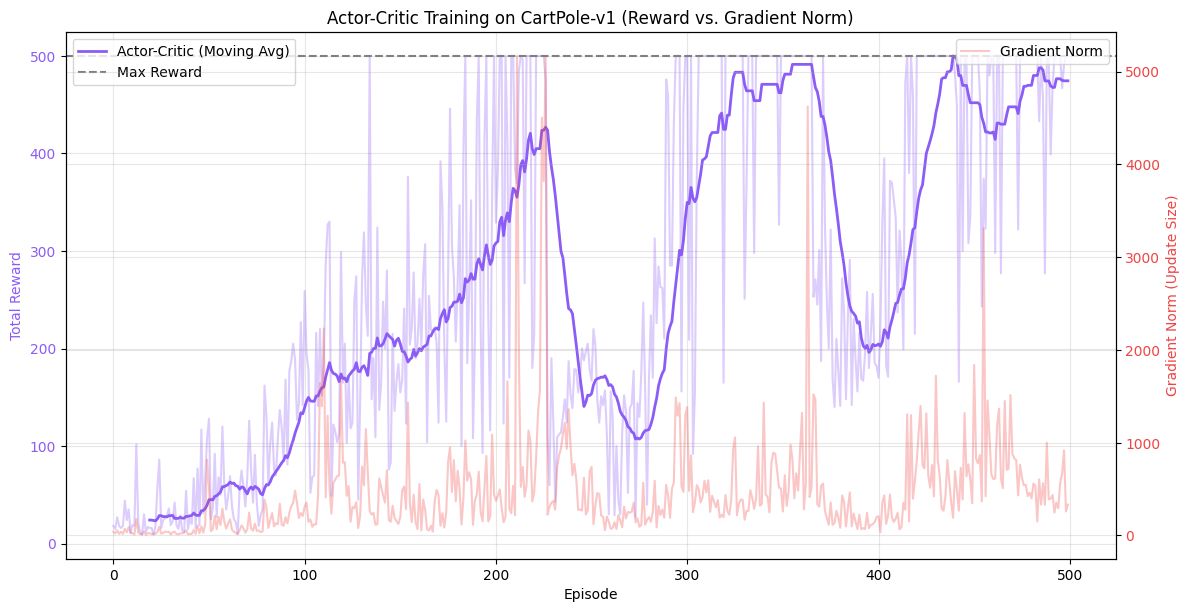

In [15]:
trained_net, ac_rewards, grad_norms = train_actor_critic(num_episodes=500)

fig, ax1 = plt.subplots(figsize=(12, 6))

color1 = '#8b5cf6'
ax1.set_xlabel('Episode')
ax1.set_ylabel('Total Reward', color=color1)
ax1.plot(ac_rewards, color=color1, alpha=0.3)

window = 20
if len(ac_rewards) >= window:
    smoothed = np.convolve(ac_rewards, np.ones(window)/window, mode='valid')
    ax1.plot(np.arange(window-1, len(ac_rewards)), smoothed, color=color1, linewidth=2, label=f'Actor-Critic (Moving Avg)')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.axhline(500, color='gray', linestyle='--', label="Max Reward")
ax1.legend(loc='upper left')

ax2 = ax1.twinx()  
color2 = '#ef4444'
ax2.set_ylabel('Gradient Norm (Update Size)', color=color2)  
ax2.plot(grad_norms, color=color2, alpha=0.3, label='Gradient Norm')
ax2.tick_params(axis='y', labelcolor=color2)
ax2.legend(loc='upper right')

fig.tight_layout()  
plt.title("Actor-Critic Training on CartPole-v1 (Reward vs. Gradient Norm)")
plt.show()

## 4. Watch the Agent Play!

Let's see our dual-headed Actor-Critic in action.

In [16]:
def render_agent(env_name, agent):
    env = gym.make(env_name, render_mode='rgb_array')
    state, _ = env.reset(seed=42)
    frames = []
    
    done = False
    truncated = False
    while not (done or truncated) and len(frames) < 500:
        frames.append(env.render())
        state_tensor = torch.FloatTensor(state).unsqueeze(0)
        with torch.no_grad():
            action, _, _ = agent.act(state_tensor)
        state, _, done, truncated, _ = env.step(action)
    env.close()
    
    fig, ax = plt.subplots(figsize=(6,4))
    ax.axis('off')
    img = ax.imshow(frames[0])
    
    def animate(i):
        img.set_data(frames[i])
        return [img]
        
    anim = animation.FuncAnimation(fig, animate, frames=len(frames), interval=50, blit=True)
    plt.close() # Prevent extra static plot from showing
    return HTML(anim.to_jshtml())

render_agent('CartPole-v1', trained_net)


## Conclusion

Notice how quickly Actor-Critic zoomed up compared to pure REINFORCE! 

By introducing the Critic to act as a "baseline", we crushed the variance of Policy Gradients. The agent no longer has to wait until the end of the episode to figure out if it messed up. The Critic evaluates every single step instantly.

But we aren't completely safe yet. Actor-Critic networks are incredibly delicate. 

If you look closely at the learning curve, you will likely see massive, catastrophic dips (e.g., dropping from a perfect 500 down to 200 around episode 400). This is known as a **Policy Collapse**.

Why does this happen? The Advantage $\delta$ tells the Actor how good a move was. If the Advantage is massive, the math tells the Actor to take a huge mathematical step in that direction to make that action more likely.

However, Neural Networks are highly non-linear. If the Actor takes an update step that is *too large*, it completely warps the geometry of its weights. That massive update might have made the network great at situation $X$, but it irreversibly scrambled the weights that previously told it how to handle situation $Y$. The policy "shatters", and the agent instantly forgets how to balance the pole.

Because it now plays so poorly, the data it collects is terrible, and the Critic's predictions become inaccurate, creating a death spiral that takes dozen of episodes to recover from.

### What's Next?
How can we put "guardrails" on the Actor so it is literally mathematically forbidden from taking a step that breaks its policy?

In **Notebook 09**, we introduce Proximal Policy Optimization (**PPO**), the most famous, most robust, and most widely used Deep RL algorithm on Earth—powering everything from ChatGPT to Dota bots.